                               ======= Devoir Libre =======

### ====== Rappel: 
### 1) Qualitative × Qualitative

* **Test du χ² d’indépendance** (table de contingence).
* Conditions : observations indépendantes ; fréquences attendues suffisantes (règle pratique : la majorité ≥ 5).
* Taille d’effet : **V de Cramér**.

### 2) Quantitative × qualitative à 2 modalités

* Comparaison de moyennes entre 2 groupes indépendants.
* Conditions : normalité (par groupe) ; homogénéité des variances (Levene/Brown-Forsythe).
* Choix :

  * variances égales ⇒ **t de Student**
  * variances inégales ⇒ **t de Welch**
  * normalité fortement violée (petits n) ⇒ **Mann–Whitney**
* Taille d’effet : **Cohen’s d** (ou **Hedges g** si petits effectifs).

### 3) Quantitative × qualitative à 3 modalités

* Comparaison de **k moyennes**.
* Conditions : normalité par groupe + homogénéité des variances.
* Choix :

  * OK ⇒ **ANOVA à un facteur**
  * variances inégales ⇒ **ANOVA de Welch**
  * normalité non respectée ⇒ **Kruskal–Wallis**
* Post-hoc :

  * ANOVA ⇒ **Tukey HSD**
  * Welch ⇒ **Games–Howell**
  * Kruskal ⇒ **Dunn** (Holm/Bonferroni)
* Taille d’effet :

  * ANOVA/Welch ⇒ **η²p** (ou ω²)
  * Kruskal ⇒ **ε²** (epsilon squared)

### 4) Corrélation Quantitative × quantitative

* Relation linéaire : **corrélation de Pearson** (si normalité/linéarité raisonnable).
* Sinon monotone : **Spearman**.
* Taille d’effet : **r** (le coefficient lui-même).

### 5) Deux mesures sur les mêmes individus

* Deux mesures **sur les mêmes individus** ⇒ test **apparié**.
* Condition principale : normalité des **différences**.
* Choix :

  * OK ⇒ **t apparié**
  * Sinon ⇒ **Wilcoxon signed-rank**
* Taille d’effet : **Cohen’s d apparié (dz)**.


### 6) Plusieurs mesures(>3) sur les mêmes individus

Plusieurs mesures(>3) **sur les mêmes individus ⇒ **ANOVA à mesures répétées** (paramétrique) ou **Friedman** (non paramétrique).


* Données **intra-sujets** (répétées).
* Choix :

  * hypothèses paramétriques acceptables ⇒ **ANOVA MR**
  * sinon ⇒ **Friedman**
* Post-hoc :

  * MR-ANOVA ⇒ tests t appariés pairwise + correction (Holm)
  * Friedman ⇒ Wilcoxon pairwise + correction (Holm)

In [1]:
 ### Chargement + typage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (shapiro, ttest_ind, ttest_rel,f_oneway,
                          levene, mannwhitneyu, chi2_contingency,
                         pearsonr, spearmanr, wilcoxon,kruskal)
from scipy import stats
import pingouin as pg

df = pd.read_csv("sport.csv")
df.head()

,ID,SEXE,AGE,SCORE_INITIAL,METHODE_ENTRAINEMENT,SCORE_APRES_1MOIS,SCORE_APRES_2MOIS
0,1.0,Masculin,21.0,47.201953,Méthode 2,55.850902,61.985365
1,2.0,Masculin,24.0,57.259589,Méthode 2,54.081379,63.841752
2,3.0,Masculin,20.0,53.420624,Méthode classique,46.738289,57.875318
3,4.0,Masculin,25.0,50.107122,Méthode 2,51.638073,57.420648
4,5.0,Masculin,23.0,54.217191,Méthode 1,51.713579,61.977230


In [2]:
print(df.dtypes)
# Types
df["SEXE"] = df["SEXE"].astype("category")
df["METHODE_ENTRAINEMENT"] = df["METHODE_ENTRAINEMENT"].astype("category")
print(f"\n{df.dtypes}")

ID                      float64
SEXE                        str
AGE                     float64
SCORE_INITIAL           float64
METHODE_ENTRAINEMENT        str
SCORE_APRES_1MOIS       float64
SCORE_APRES_2MOIS       float64
dtype: object

ID                       float64
SEXE                    category
AGE                      float64
SCORE_INITIAL            float64
METHODE_ENTRAINEMENT    category
SCORE_APRES_1MOIS        float64
SCORE_APRES_2MOIS        float64
dtype: object


#### 1.	Est ce que les deux variables scores initiale, score après un mois et le score après deux mois sont normalement distribuée?

In [3]:
## tester la normalité
p_value,stat=shapiro(df["SCORE_INITIAL"])
print(f"p-value de l'age={p_value.round(3)}")

p-value de l'age=0.984


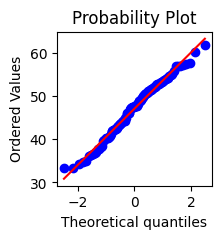

In [4]:
plt.figure(figsize=(2,2))
stats.probplot(df["SCORE_INITIAL"],dist="norm",plot=plt)
plt.show()

In [5]:
## tester la normalité
p_value,stat=shapiro(df["SCORE_APRES_1MOIS"])
print(f"p-value de l'age={p_value.round(3)}")

p-value de l'age=0.988


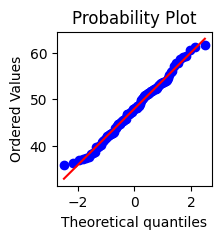

In [6]:
plt.figure(figsize=(2,2))
stats.probplot(df["SCORE_APRES_1MOIS"],dist="norm",plot=plt)
plt.show()

In [7]:
## tester la normalité 
p_value,stat=shapiro(df["SCORE_APRES_2MOIS"])
print(f"p-value de l'age={p_value.round(3)}")

p-value de l'age=0.969


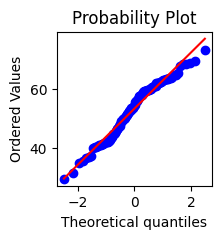

In [8]:
plt.figure(figsize=(2,2))
stats.probplot(df["SCORE_APRES_2MOIS"],dist="norm",plot=plt)
plt.show()

Comme $p-value> 0.5$, les 3 variables sont normalement distribuées!

#### 2.	Est ce qu’il y a une corrélation significative entre le scores initiale et le score après un mois? 

Comme les deux variables sont normalement disribuées, en utilise le test de corrélation de pearson:

In [9]:
r,p=pearsonr(df["SCORE_INITIAL"],df["SCORE_APRES_1MOIS"])
print(p.round(3))

0.0


In [10]:
print(r.round(3))

0.451


In [11]:
ro,p=spearmanr(df["SCORE_INITIAL"],df["SCORE_APRES_1MOIS"])
print(p.round(3))

0.0


In [12]:
print(ro.round(3))

0.442


N.B: Comme $p-value \le 0.05$ et $r=0.451$, alors il existe une corrélation positive faible mais statistiquement significative entre les deux variables.

#### 3.	Est ce qu’il y a une relation significative entre le sexe et la méthode d’entraînement?
- On applique le test de kh-deux et on vérifie ses conditions d'application

In [13]:
tab = pd.crosstab(df["SEXE"], df["METHODE_ENTRAINEMENT"])
chi2, p, dof, expected = stats.chi2_contingency(tab)

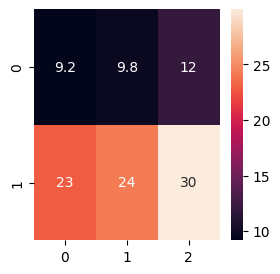

In [14]:
# Afficher les effectifs théoriques:
plt.figure(figsize=(3,3))
sns.heatmap(expected,annot=True)
plt.show()

N.B: tous les effectifs théoriques > 5

In [15]:
## afficher la p-value
print(p.round(3))

0.305


N.B comme $p-value>0.05$ alors il n'y a pas de reltion significative entre les deux variables!

In [16]:
# Taill de l'effet en cas d'une relation significative: V de Cramér 
n = tab.to_numpy().sum()
r, k = tab.shape
cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))

print(cramers_v.round(3))

0.148


#### 4. Est ce qu’il y a une association significative enre  l’âge et le sexe?
- Vérifier la normalité de l'âge pour chaque modalité de la variable sexe
- Vérifier l'égalités de variances de la variable âge pour les deux groupes de la variables sexe

In [17]:
# construire les groupes
print(df["SEXE"].unique())
age_h=df[df["SEXE"]=="Masculin"]["AGE"]
age_f=df[df["SEXE"]=="Féminin"]["AGE"]

['Masculin', 'Féminin']
Categories (2, str): ['Féminin', 'Masculin']


In [18]:
# Tester la normalité
sta_h,p_h=shapiro(age_h)
sta_f,p_f=shapiro(age_f)
print(p_h.round(3))
print(p_f.round(3))

0.0
0.017


- Les 2 distributions ne sont pas normales, alors on peut pas appliquer le test t pour 2 échantillons indépendents
- On applique le test de de mannwhitney

In [19]:
stat,p_vlue=mannwhitneyu(age_h,age_f)
print(p_vlue.round(3))

0.631


In [20]:
stat,p_vlue=ttest_ind(age_h,age_f)
print(p_vlue.round(3))

0.634


In [21]:
stat,p_vlue=ttest_ind(age_h,age_f,equal_var=False)
print(p_vlue.round(3))

0.641


- Il n'y a pas d'effet signiicative de la variable sexe sur l'âge!

#### 5.	Est ce qu’il y a une association significative enre  l’âge et la méthode d’entraînement?
- tester la normalité de la variable âge pour chaque modalité de la variable "méthode d'entrainement"
- tester l'égalité des variables de la vriable âge pour les différentes méthodes d'entrainement

In [22]:
# Construire les groupes
print(df["METHODE_ENTRAINEMENT"].unique())
age_m1=df[df["METHODE_ENTRAINEMENT"]=='Méthode 1']["AGE"]
age_m2=df[df["METHODE_ENTRAINEMENT"]=='Méthode 2']["AGE"]
age_c=df[df["METHODE_ENTRAINEMENT"]=='Méthode classique']["AGE"]

['Méthode 2', 'Méthode classique', 'Méthode 1']
Categories (3, str): ['Méthode 1', 'Méthode 2', 'Méthode classique']


In [23]:
## tester la normalité
_,p_m1=shapiro(age_m1) # _ pour ignorer volontairement la statistique, elle ne sera pas utilisée
_,p_m2=shapiro(age_m2)
_,p_c=shapiro(age_c)
print(p_m1.round(3))
print(p_m2.round(3))
print(p_c.round(3))

0.01
0.05
0.02


- La normalité n'est pas vérifiée pour tous les groupes, alors on utilise le test de Kruskal–Wallis pour tester l'association entre l'âge et la méthode d'entrainement

In [24]:
## Code Kruskal–Wallis
stat, p_value = kruskal(age_m1,age_m2,age_c)
print(f"p-value = {p_value:.4f}")

p-value = 0.9438


- comme $p-value >0.05$ alors, il n'y pas d'association significative entre l'âge et la méthode d'entrainement

#### 6. Est ce qu’il y a une corrélation significtive entre l’âge et le score initial?
- Tester la normalité des deux variables

In [25]:
_,p_age=shapiro(df["AGE"])
_,p_scoreIn=shapiro(df["SCORE_INITIAL"])
print(p_age.round(3))
print(p_scoreIn.round(3))

0.0
0.227


- La variable score initial n'est pas normale! alors on applique de teste de corrélation de spearman 

In [26]:
rho,p=spearmanr(df["AGE"],df["SCORE_INITIAL"])
print(p.round(3))

0.987


- Il n'y a pas de corrélation significative entre les 2 variables!

#### 7.	Est ce qu’il y a une association significative enre  le  score initial et la méthode d’entraînement?
- Tester la normalité de la vriable score initial pour les différentes groupes de la méthode d'entrainement
- tester l'égalité des variances 

In [27]:
## construire les groupes 
score_m1=df[df["METHODE_ENTRAINEMENT"]=='Méthode 1']['SCORE_INITIAL']
score_m2=df[df["METHODE_ENTRAINEMENT"]=='Méthode 2']['SCORE_INITIAL']
score_c=df[df["METHODE_ENTRAINEMENT"]=='Méthode classique']['SCORE_INITIAL']

In [28]:
_,p_m1=shapiro(score_m1) # _ pour ignorer volontairement la statistique, elle ne sera pas utilisée
_,p_m2=shapiro(score_m2)
_,p_c=shapiro(score_c)
print(p_m1.round(3))
print(p_m2.round(3))
print(p_c.round(3))

0.125
0.575
0.963


- La normalité est vérifiée!

In [29]:
# Homogénéité des variances 
stat,pval = stats.levene(score_m1,score_m2,score_c,center="median")
print(pval.round(2))

0.87


- L'hypothèse d'égalité de variance est vérifiée!

In [30]:
## Test d'ANOVA à facteur
stat, p_value = f_oneway(score_m1,score_m2,score_c)
print("F-stat:", stat.round(2))
print("p-value:", p_value.round(4))

F-stat: 0.18
p-value: 0.8373


- Il n'y a pas d'effet de la méthode d'entrainement sur le score initial!

#### 8.	Analyser l’évolution globale du score (initial → 1 mois)
- tester la normalité de la variable différence=score 1 mois- score initial

In [31]:
diff=df["SCORE_APRES_1MOIS"]-df["SCORE_INITIAL"]
_,p_dif=shapiro(diff)
print(p_dif)

0.4761380351480862


- La normalité est vérifiée alors on utilise le test t pour 2 échantillons dépendents ou appariés

In [32]:
# test t apparié
stat_t, p_value = stats.ttest_rel(df["SCORE_APRES_1MOIS"], df["SCORE_INITIAL"], nan_policy="omit")
print(p_value)

0.17927875499776158


- il n'y a pas de différence significative entre les deux scores, alors, il n'y pas d'effet d'entrainement!

#### 9. Analyser l’évolution globale du score (initial → 2 mois)
- tester la normalité de la variable différence=score 2 mois- score initial

In [33]:
diff=df["SCORE_APRES_2MOIS"]-df["SCORE_INITIAL"]
print(np.mean(diff)) 

6.126838008891377


In [34]:
_,p_dif=shapiro(diff)
print(p_dif)

0.9737431253171001


- La normalité est vérifiée alors on utilise le test t pour 2 échantillons dépendents ou appariés

In [35]:
_, p_value = stats.ttest_rel(df["SCORE_INITIAL"], df["SCORE_APRES_2MOIS"])
print(p_value)

3.1535807224192647e-11


- Il y a  une évolution globale  positive significatif du score globale (initial → 2 mois)

In [36]:
# Test de Wilcoxon
stat, p_value = wilcoxon(df["SCORE_INITIAL"], df["SCORE_APRES_2MOIS"])
print(f"Statistique W = {stat}")
print(f"p-value = {p_value.round(3)}")

Statistique W = 907.0
p-value = 0.0


In [37]:
## Taille de l'efft : Cohen’s d apparié (dz)
dz = diff.mean() / diff.std(ddof=1) # Delta Degrees Of Freedom =1 pour calculer l'ecart de l'échantillon et pas de la population
print(dz.round(3))

0.713


- on $|dz|<0.2 $ il ya une différence significative mais **peu importante**!

#### 10. Est ce qu’il y un effet significative de la méthode d’entraînement sur le score  après 1 mois
- tester la normalité
- tester l'égalité de variances

In [38]:
## construire les groupes 
score_m1=df[df["METHODE_ENTRAINEMENT"]=='Méthode 1']["SCORE_APRES_1MOIS"]
score_m2=df[df["METHODE_ENTRAINEMENT"]=='Méthode 2']["SCORE_APRES_1MOIS"]
score_c=df[df["METHODE_ENTRAINEMENT"]=='Méthode classique']["SCORE_APRES_1MOIS"]

In [39]:
# Tester la normalité
_,p_m1=shapiro(score_m1) # _ pour ignorer volontairement la statistique, elle ne sera pas utilisée
_,p_m2=shapiro(score_m2)
_,p_c=shapiro(score_c)
print(p_m1.round(3))
print(p_m2.round(3))
print(p_c.round(3))

0.641
0.457
0.569


- La normalité est vérifiée

In [40]:
# Homogénéité des variances 
stat,pval = stats.levene(score_m1,score_m2,score_c,center="median")
print(pval.round(2))

0.93


- L'hypothèse d'Homogénéité des variances  est vérifiée

In [41]:
## Test d'ANOVA à facteur
stat, p_value = f_oneway(score_m1,score_m2,score_c)
print("F-stat:", stat.round(2))
print("p-value:", p_value.round(4))

F-stat: 0.16
p-value: 0.8519


- Il n'y pas d'effet significatif de la méthode d'entrainement sur le score après 1 mois

#### 11. Est ce qu’il y un effet significative de la méthode d’entraînement sur le score  après 2 mois
- tester la normalité
- tester l'égalité de variances

In [42]:
## construire les groupes 
score_m1=df[df["METHODE_ENTRAINEMENT"]=='Méthode 1']["SCORE_APRES_2MOIS"]
score_m2=df[df["METHODE_ENTRAINEMENT"]=='Méthode 2']["SCORE_APRES_2MOIS"]
score_c=df[df["METHODE_ENTRAINEMENT"]=='Méthode classique']["SCORE_APRES_2MOIS"]

In [43]:
# Tester la normalité
_,p_m1=shapiro(score_m1) # _ pour ignorer volontairement la statistique, elle ne sera pas utilisée
_,p_m2=shapiro(score_m2)
_,p_c=shapiro(score_c)
print(p_m1.round(3))
print(p_m2.round(3))
print(p_c.round(3))

0.0
0.917
0.94


- La normalité n'est pas vérfiée alors on utilise le test de Kruskal–Wallis

In [44]:
## Code Kruskal–Wallis
H, p_value = kruskal(score_m1,score_m2,score_c)
print(f"p-value = {p_value:.4f}")

p-value = 0.0000


- Il y a une effet significatif de la méthode d'entrainement sur le score après 2 mois
- On utilise le test post-hoc de Dunn

In [45]:
import sys
!{sys.executable} -m pip install scikit-posthocs


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import scikit_posthocs as sp

dunn_results = sp.posthoc_dunn(
    df,
    val_col="SCORE_APRES_2MOIS",
    group_col="METHODE_ENTRAINEMENT",
    p_adjust="holm"
)
print(dunn_results)

                   Méthode 1  Méthode 2  Méthode classique
Méthode 1           1.000000   0.940355           0.000002
Méthode 2           0.940355   1.000000           0.000002
Méthode classique   0.000002   0.000002           1.000000


- il y a une différence significative entre la méthode 1 et la méthode classique en terme de score 2 mois
- il y a une différence significative entre la méthode 2 et la méthode classique en terme de score 2 mois

In [47]:
## comparaison des moyennes
df.groupby("METHODE_ENTRAINEMENT")["SCORE_APRES_2MOIS"].mean()

METHODE_ENTRAINEMENT
Méthode 1            56.938459
Méthode 2            57.657733
Méthode classique    46.830261
Name: SCORE_APRES_2MOIS, dtype: float64

- Les deux méthodes 1 et 2 donner un score 2 mois  élevé en comparaison avec la méthode classique!

In [48]:
## taille de l'effet: epsilon squared
n=len(df)
k=len(df["METHODE_ENTRAINEMENT"].unique())

epsilon_2 =(H-k+1)/(n-1)
epsilon_2 = max(0, epsilon_2)
print(epsilon_2)

0.2989466323936574


- $  0 \le \epsilon_2 \le 1 $ :
  
| $\epsilon_2 $ | Taille de l’effet |
| --------------------------- | ----------------- |
| ≈ 0.01                      | faible            |
| ≈ 0.08                      | moyenne           |
| ≥ 0.26                      | grande            |


- Comme il est proche de 0 dans notre cas, alors il y a une très faible association!

1-	Est ce qu’il y a une relation significative entre le gain final et la méthode d’entrainement? 
      
      GAIN_FINAL = SCORE_APRES_2MOIS - SCORE_INITIAL

In [49]:
df["GAIN_FINAL"]=df["SCORE_APRES_2MOIS"]-df["SCORE_INITIAL"]
df.head()

,ID,SEXE,AGE,SCORE_INITIAL,METHODE_ENTRAINEMENT,SCORE_APRES_1MOIS,SCORE_APRES_2MOIS,GAIN_FINAL
0,1.0,Masculin,21.0,47.201953,Méthode 2,55.850902,61.985365,14.783412
1,2.0,Masculin,24.0,57.259589,Méthode 2,54.081379,63.841752,6.582163
2,3.0,Masculin,20.0,53.420624,Méthode classique,46.738289,57.875318,4.454694
3,4.0,Masculin,25.0,50.107122,Méthode 2,51.638073,57.420648,7.313526
4,5.0,Masculin,23.0,54.217191,Méthode 1,51.713579,61.977230,7.760040


- test de normalité
- test d'égalité de variances

In [50]:
## construire les groupes 
score_m1=df[df["METHODE_ENTRAINEMENT"]=='Méthode 1']["GAIN_FINAL"]
score_m2=df[df["METHODE_ENTRAINEMENT"]=='Méthode 2']["GAIN_FINAL"]
score_c=df[df["METHODE_ENTRAINEMENT"]=='Méthode classique']["GAIN_FINAL"]

In [51]:
# Tester la normalité
_,p_m1=shapiro(score_m1) # _ pour ignorer volontairement la statistique, elle ne sera pas utilisée
_,p_m2=shapiro(score_m2)
_,p_c=shapiro(score_c)
print(p_m1.round(3))
print(p_m2.round(3))
print(p_c.round(3))

0.724
0.754
0.158


- Normalité vérifiée

In [52]:
# Homogénéité des variances 
stat,pval = stats.levene(score_m1,score_m2,score_c,center="median")
print(pval.round(2))

0.23


- Egalité de variance vérifiée!

In [53]:
## Test d'ANOVA à facteur
stat, p_value = f_oneway(score_m1,score_m2,score_c)
print("F-stat:", stat.round(2))
print("p-value:", p_value.round(4))

F-stat: 23.97
p-value: 0.0


- Il y a un effet significatif de ma méthode d'entrainement sur le score final
- On utilise un test post-hoc de Tukey HSD

In [54]:
## pip install statsmodels
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["GAIN_FINAL"],   # variable quantitative
    groups=df["METHODE_ENTRAINEMENT"], # groupes
    alpha=0.05
)
print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1        group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------
Méthode 1         Méthode 2   0.2127 0.9921  -3.9981  4.4235  False
Méthode 1 Méthode classique  -9.7171    0.0 -13.7288 -5.7054   True
Méthode 2 Méthode classique  -9.9298    0.0  -13.874 -5.9857   True
-------------------------------------------------------------------


- il y a une différence significative entre la méthode 1 et la méthode classique en terme de score finale
-  il y a une différence significative entre la méthode 2 et la méthode classique en terme de score finale
-  les méthodes 1 et 2 donnent un meilleur score final en comparaison avec la méthode classique

In [55]:
# Taille de l'effte: Eta carré (η²) ou Eta carré partiel (η²ₚ)

**Interprétation (rappel)**

$\eta^2 ≈ 0.01$ : effet faible

$\eta^2 ≈ 0.06$ : effet moyen

$\eta^2≥ 0.14$ : effet fort

In [56]:
def eta_squared(*groups):
    # groups est un tuple permet de recevoir autant d’arguments que nécessaire
    """
    Calcule eta squared (η²) pour une ANOVA à un facteur
    """
    # Moyenne globale
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
# Somme des carrés inter-groupes
    ss_between=0
    for g in groups:
        ss_between =ss_between + len(g) * (np.mean(g) - grand_mean)**2

    # Somme des carrés totale
    ss_total = sum((all_data - grand_mean)**2)

    # Eta squared
    eta2 = ss_between / ss_total

    return eta2

In [57]:
eta_2=eta_squared(score_m1,score_m2,score_c)
print(eta_2)

0.313458953308015
